Partie 1 – Explorer les données 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [11]:
#Chargement des données CSV
df = pd.read_csv("../data/smart_building_raw.csv")
print("Dimensions :", df.shape)

Dimensions : (507, 14)


In [12]:
#Affichage des premières lignes du dataset
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


In [13]:
#Affichage desS dernières lignes du dataset
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


In [14]:
# Point 5 : combien de variables (colonnes) possède le dataset ?
# df.shape[1] correspond au nombre de colonnes
print(f"Nombre de variables : {df.shape[1]}")

Nombre de variables : 14


In [15]:
# Point 6 : identifier les variables numeriques
# On utilise df.dtypes pour voir le type de chaque colonne,
# puis on liste manuellement celles qui sont vraiment numeriques (mesures continues)
print(df.dtypes)


id_mesure               int64
date                   object
batiment               object
type_batiment          object
zone                   object
temperature           float64
humidite              float64
co2                   float64
occupation            float64
consommation_kwh      float64
mode_climatisation     object
etat_systeme           object
jour_semaine           object
alerte                 object
dtype: object


In [16]:
# On definit explicitement la liste des variables numeriques du dataset
variables_numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]
print("Variables numeriques :", variables_numeriques)

Variables numeriques : ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


In [17]:
# Point 7 : identifier les variables categorielles
# Ce sont les colonnes qui representent des categories (texte, classes), pas des mesures continues
variables_categorielles = ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine", "alerte"]
print("Variables categorielles :", variables_categorielles)

Variables categorielles : ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


In [18]:
# Point 8 : identifier la ou les variables de type date
variable_date = "date"
print("Variable de type date :", variable_date)
print(df[variable_date].head())

Variable de type date : date
0    2025-02-13 06:00:00
1    2025-03-10 12:00:00
2    2025-05-04 00:00:00
3    2025-01-19 00:00:00
4    2025-04-24 06:00:00
Name: date, dtype: object


In [19]:
# Point 9 : identifier la ou les variables qui servent d'identifiant
variable_id = "id_mesure"
print("Variable identifiant :", variable_id)
print("Nombre de valeurs uniques :", df[variable_id].nunique())
print("Nombre total de lignes    :", df.shape[0])

Variable identifiant : id_mesure
Nombre de valeurs uniques : 500
Nombre total de lignes    : 507


In [20]:
# Point 10 : statistiques descriptives des variables numeriques
# describe() calcule automatiquement : count, mean, std, min, 25%, 50% (mediane), 75%, max
df[variables_numeriques].describe()

,temperature,humidite,co2,occupation,consommation_kwh
count,495.000000,496.000000,500.000000,501.000000,502.000000
mean,24.154141,57.864113,844.150000,44.850299,169.069323
std,7.418465,16.026336,582.181386,24.949139,53.164294
min,-30.000000,-12.000000,89.000000,-20.000000,-100.000000
25%,21.600000,49.275000,623.750000,27.000000,136.875000
50%,24.000000,57.550000,787.500000,46.000000,169.800000
75%,26.000000,65.750000,952.000000,61.000000,202.975000
max,96.000000,160.000000,6000.000000,116.000000,336.200000


## Point 11 — Variables potentiellement problématiques

D'après les statistiques descriptives (point 10) et un premier coup d'œil sur les données :

- **temperature** : le minimum et le maximum semblent très extrêmes pour un bâtiment (ex. valeurs négatives fortes ou supérieures à 70°C) → probablement des erreurs de capteur.
- **humidite** : l'humidité relative doit être comprise entre 0 et 100 % ; or on observe des valeurs négatives et des valeurs bien au-dessus de 100 → incohérent physiquement.
- **co2** : certaines valeurs atteignent plusieurs milliers de ppm, largement au-dessus des niveaux réalistes en intérieur → suspect.
- **consommation_kwh** : présence de valeurs négatives, alors qu'une consommation ne peut pas être négative.
- **occupation** : présence de valeurs négatives, alors qu'un nombre de personnes ne peut pas être négatif.
- **type_batiment**, **mode_climatisation**, **jour_semaine** : catégories mal orthographiées ou avec une casse incohérente (ex. "École" / "ÉCOLE" / "ecole").
- **date** : certaines valeurs ne sont pas des dates valides (ex. "date_invalide", "31/99/2025").

Ces problèmes seront traités un par un dans les points suivants (incohérences, valeurs manquantes, doublons, valeurs aberrantes).

In [21]:
# Point 12a : rechercher les valeurs d'humidite negatives (physiquement impossible)
humidite_negative = df["humidite"] < 0
print("Nombre de valeurs d'humidite negatives :", humidite_negative.sum())
df.loc[humidite_negative, ["id_mesure", "humidite"]]

Nombre de valeurs d'humidite negatives : 3


,id_mesure,humidite
281,1126,-5.0
335,1036,-8.0
366,1216,-12.0


In [22]:
# Point 12b : rechercher les valeurs d'humidite superieures a 100 (physiquement impossible)
humidite_superieure_100 = df["humidite"] > 100
print("Nombre de valeurs d'humidite > 100 :", humidite_superieure_100.sum())
df.loc[humidite_superieure_100, ["id_mesure", "humidite"]]

Nombre de valeurs d'humidite > 100 : 7


,id_mesure,humidite
59,1246,108.0
103,1016,145.0
128,1156,160.0
160,1186,125.0
268,1276,140.0
327,1066,132.0
342,1096,110.0


In [23]:
# Point 12c : rechercher les temperatures extremement elevees (ou basses) pour un batiment
# Seuils physiquement realistes pour l'interieur d'un batiment : entre -10 et 45 degres
temperature_aberrante = (df["temperature"] < -10) | (df["temperature"] > 45)
print("Nombre de temperatures aberrantes :", temperature_aberrante.sum())
df.loc[temperature_aberrante, ["id_mesure", "temperature"]]

Nombre de temperatures aberrantes : 6


,id_mesure,temperature
7,1141,72.5
116,1181,96.0
161,1061,88.0
185,1221,-25.0
358,1101,-30.0
499,1021,95.2


In [24]:
# Point 12d : rechercher les valeurs d'occupation negatives (un nombre de personnes ne peut pas etre negatif)
occupation_negative = df["occupation"] < 0
print("Nombre de valeurs d'occupation negatives :", occupation_negative.sum())
df.loc[occupation_negative, ["id_mesure", "occupation"]]

Nombre de valeurs d'occupation negatives : 5


,id_mesure,occupation
22,1031,-5.0
376,1231,-8.0
430,1081,-12.0
487,1131,-2.0
494,1331,-20.0


In [25]:
# Point 12e : rechercher les valeurs de consommation energetique negatives (impossible physiquement)
consommation_negative = df["consommation_kwh"] < 0
print("Nombre de valeurs de consommation negatives :", consommation_negative.sum())
df.loc[consommation_negative, ["id_mesure", "consommation_kwh"]]

Nombre de valeurs de consommation negatives : 4


,id_mesure,consommation_kwh
59,1246,-15.0
154,1046,-50.0
199,1146,-20.0
441,1346,-100.0


In [26]:
# Point 12f : transformer les valeurs manifestement erronees en valeurs manquantes (NaN)
# On ne peut pas deviner la vraie valeur d'origine, donc on ne "corrige" pas au hasard :
# on marque ces valeurs comme manquantes, elles seront traitees comme telles (imputation) plus tard.

df.loc[humidite_negative, "humidite"] = np.nan
df.loc[humidite_superieure_100, "humidite"] = np.nan
df.loc[temperature_aberrante, "temperature"] = np.nan
df.loc[occupation_negative, "occupation"] = np.nan
df.loc[consommation_negative, "consommation_kwh"] = np.nan

print("Nombre total de valeurs transformees en NaN pour :")
print(" - humidite         :", humidite_negative.sum() + humidite_superieure_100.sum())
print(" - temperature       :", temperature_aberrante.sum())
print(" - occupation        :", occupation_negative.sum())
print(" - consommation_kwh  :", consommation_negative.sum())

Nombre total de valeurs transformees en NaN pour :
 - humidite         : 10
 - temperature       : 6
 - occupation        : 5
 - consommation_kwh  : 4


In [27]:
# Point 12g : rechercher les categories mal orthographiees ou avec une casse incoherente
# On regarde les valeurs uniques de chaque variable categorielle pour reperer les anomalies
for c in ["type_batiment", "mode_climatisation", "jour_semaine"]:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- type_batiment ---
type_batiment
Bureau               210
Centre commercial     65
École                 59
Hôpital               58
Entrepôt              52
Université            48
NaN                    4
BUREAU                 2
ecole                  1
ÉCOLE                  1
Bureu                  1
bureau                 1
 UNIVERSITÉ            1
hôpital                1
centre commercial      1
 Bureau                1
entrepot               1
Name: count, dtype: int64

--- mode_climatisation ---
mode_climatisation
Normal     271
Eco        131
Boost       96
NaN          5
normal       1
BOOST        1
normale      1
Normal       1
Name: count, dtype: int64

--- jour_semaine ---
jour_semaine
Vendredi    75
Jeudi       74
Mercredi    73
Samedi      72
Dimanche    70
Lundi       69
Mardi       69
NaN          5
Name: count, dtype: int64



In [28]:
# Point 12h : normaliser les categories textuelles
# Etape 1 : supprimer les espaces en debut/fin de chaine (strip)
for c in variables_categorielles:
    df[c] = df[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Etape 2 : uniformiser la casse et corriger les fautes evidentes, categorie par categorie
corrections_type_batiment = {
    "ecole": "École", "école": "École",
    "bureau": "Bureau", "bureu": "Bureau",
    "hôpital": "Hôpital",
    "université": "Université",
    "entrepot": "Entrepôt", "entrepôt": "Entrepôt",
    "centre commercial": "Centre commercial",
}
corrections_mode_clim = {"normal": "Normal", "normale": "Normal", "boost": "Boost", "eco": "Eco"}

df["type_batiment"] = df["type_batiment"].str.lower().map(corrections_type_batiment).fillna(df["type_batiment"])
df["mode_climatisation"] = df["mode_climatisation"].str.lower().map(corrections_mode_clim).fillna(df["mode_climatisation"])

print("--- type_batiment apres nettoyage ---")
print(df["type_batiment"].value_counts(dropna=False))
print()
print("--- mode_climatisation apres nettoyage ---")
print(df["mode_climatisation"].value_counts(dropna=False))

--- type_batiment apres nettoyage ---
type_batiment
Bureau               215
Centre commercial     66
École                 61
Hôpital               59
Entrepôt              53
Université            49
NaN                    4
Name: count, dtype: int64

--- mode_climatisation apres nettoyage ---
mode_climatisation
Normal    274
Eco       131
Boost      97
NaN         5
Name: count, dtype: int64


In [29]:
# Point 13a : calculer le nombre et le pourcentage de valeurs manquantes par colonne
na_count = df.isna().sum()
na_pct = (df.isna().mean() * 100).round(2)
na_summary = pd.DataFrame({"nb_manquantes": na_count, "pct_manquantes": na_pct})
na_summary = na_summary[na_summary["nb_manquantes"] > 0].sort_values("nb_manquantes", ascending=False)
na_summary

,nb_manquantes,pct_manquantes
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


In [30]:
# Point 13b : quelle variable possede le plus de valeurs manquantes ?
variable_plus_manquante = na_summary.index[0]
print(f"Variable avec le plus de valeurs manquantes : {variable_plus_manquante}")
print(f"Nombre : {na_summary.loc[variable_plus_manquante, 'nb_manquantes']}")
print(f"Pourcentage : {na_summary.loc[variable_plus_manquante, 'pct_manquantes']}%")

Variable avec le plus de valeurs manquantes : humidite
Nombre : 21
Pourcentage : 4.14%


c) Quelle stratégie utiliser pour les valeurs manquantes ?
d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?
e) Dans quels cas utiliser la moyenne ?
f) Quand préférer la médiane ?
g) Comment traiter une variable catégorielle ?

## Points 13c à 13g — Stratégie pour les valeurs manquantes

**c) Quelle stratégie utiliser ?**
Il n'existe pas une seule bonne réponse : le choix dépend du type de variable (numérique ou catégorielle), de la proportion de valeurs manquantes, et de la distribution des données. Ici, les pourcentages sont faibles (moins de 5% par colonne), donc l'imputation (remplacement par une valeur statistique) est préférable à la suppression.

**d) Peut-on supprimer toutes les lignes avec une valeur manquante ?**
Non, ce n'est pas recommandé ici. Plusieurs colonnes différentes contiennent des `NaN`, souvent sur des lignes différentes : supprimer toute ligne concernée ferait perdre une part importante et non négligeable du dataset (plusieurs dizaines de lignes cumulées), et pourrait introduire un biais si les valeurs manquantes ne sont pas réparties au hasard.

**e) Dans quels cas utiliser la moyenne ?**
La moyenne est adaptée quand la distribution de la variable est à peu près symétrique et sans valeurs extrêmes marquées — elle est alors représentative du "centre" des données.

**f) Quand préférer la médiane ?**
La médiane est préférable dès que la distribution est asymétrique ou contient des valeurs extrêmes (outliers) : contrairement à la moyenne, elle n'est pas influencée par ces valeurs, ce qui la rend plus robuste. C'est le cas ici pour des variables comme `consommation_kwh` ou `co2`.

**g) Comment traiter une variable catégorielle ?**
On ne peut pas calculer de moyenne ou de médiane sur du texte. La stratégie standard est d'imputer par le **mode** (la catégorie la plus fréquente), ou d'introduire une catégorie explicite type `"Inconnu"` si l'on souhaite conserver la trace de l'absence d'information plutôt que de la masquer.

In [31]:
# Point 14a et 14b : identifier et afficher les doublons
# keep=False permet de marquer TOUTES les occurrences d'un doublon (pas seulement la 2eme)
doublons_stricts = df.duplicated(keep=False)
print("Nombre de lignes impliquees dans un doublon strict (toutes colonnes identiques) :", doublons_stricts.sum())
df[doublons_stricts].sort_values("id_mesure")

Nombre de lignes impliquees dans un doublon strict (toutes colonnes identiques) : 14


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,B6,Bureau,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


In [32]:
# Point 14c : sont-ils reellement identiques ?
# On verifie qu'il s'agit bien de vrais doublons (toutes colonnes identiques), pas juste un id_mesure en commun
id_dupliques = df.loc[doublons_stricts, "id_mesure"].unique()
print("id_mesure concernes par un doublon :", id_dupliques)
print("Nombre de paires de doublons :", len(id_dupliques))

# Verification : pour chaque id_mesure duplique, les lignes sont-elles bien identiques sur TOUTES les colonnes ?
for id_m in id_dupliques:
    lignes = df[df["id_mesure"] == id_m]
    identiques = lignes.drop_duplicates().shape[0] == 1
    print(f"id_mesure {id_m} : lignes strictement identiques = {identiques}")

id_mesure concernes par un doublon : [1118 1264 1456 1479 1026 1402 1320]
Nombre de paires de doublons : 7
id_mesure 1118 : lignes strictement identiques = True
id_mesure 1264 : lignes strictement identiques = True
id_mesure 1456 : lignes strictement identiques = True
id_mesure 1479 : lignes strictement identiques = True
id_mesure 1026 : lignes strictement identiques = True
id_mesure 1402 : lignes strictement identiques = True
id_mesure 1320 : lignes strictement identiques = True


In [33]:
# Point 14d : supprimer les doublons reellement identifies (garder la premiere occurrence)
avant = df.shape[0]
df = df.drop_duplicates(keep="first").reset_index(drop=True)
apres = df.shape[0]
print(f"Lignes avant : {avant} | apres suppression des doublons : {apres} | supprimees : {avant - apres}")

Lignes avant : 507 | apres suppression des doublons : 500 | supprimees : 7


In [34]:
# Point 14e : verifier que la suppression a bien fonctionne
print("Doublons restants :", df.duplicated().sum())

Doublons restants : 0


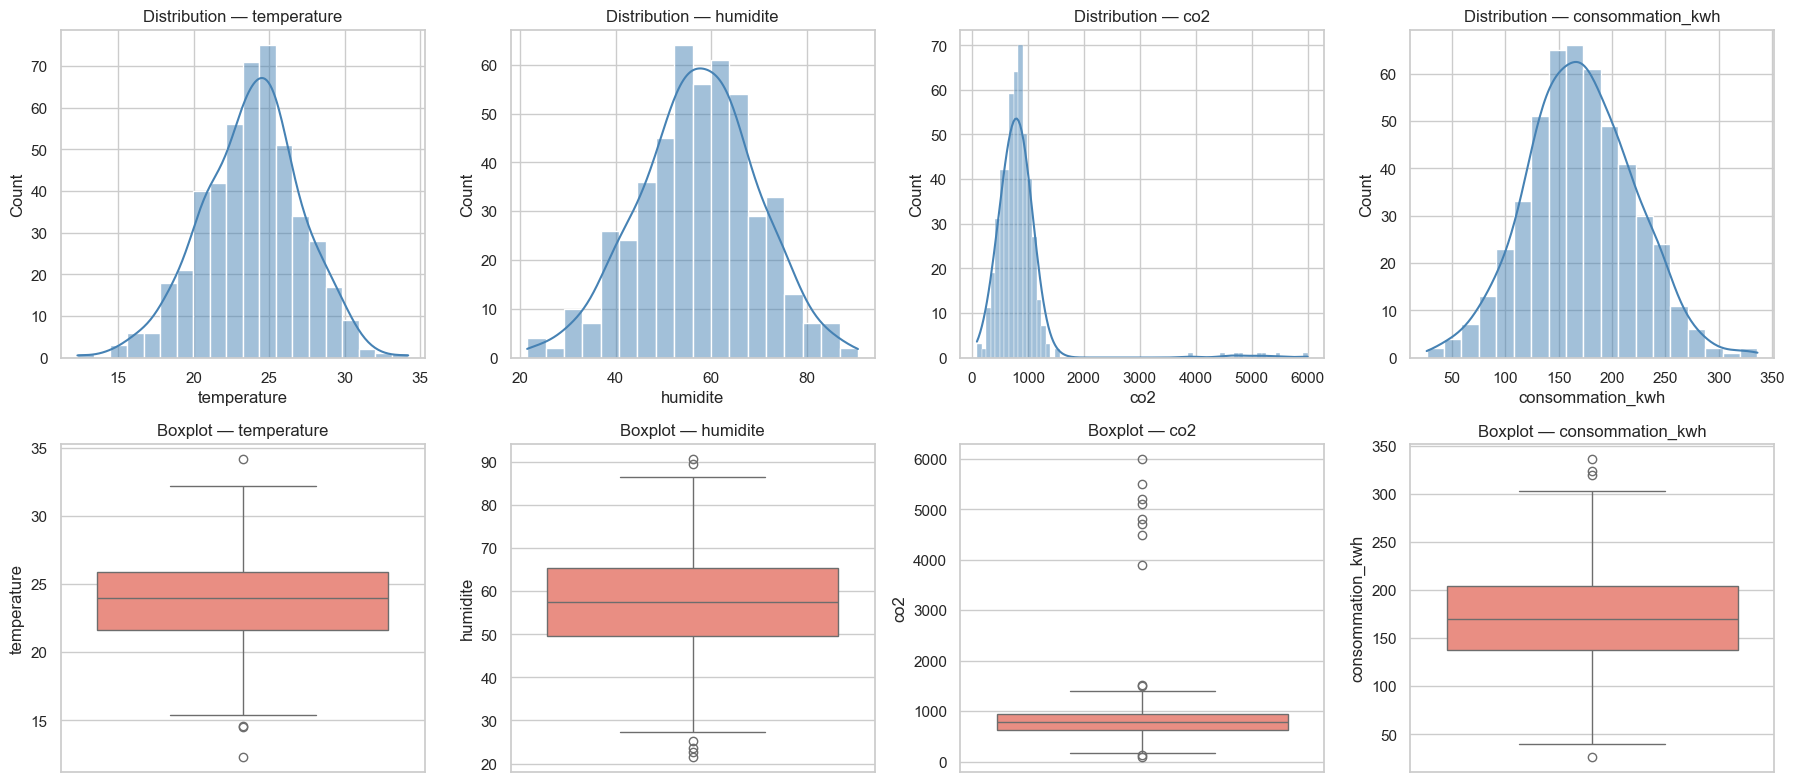

In [35]:
# Point 15 (a, b, c, d) : visualiser distributions, dispersion et valeurs extremes/aberrantes
# pour temperature, humidite, co2 et consommation_kwh
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cols_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

for i, c in enumerate(cols_a_visualiser):
    # Histogramme : montre la distribution (symetrique ou non)
    sns.histplot(df[c].dropna(), kde=True, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Distribution — {c}")
    # Boxplot : montre la dispersion, les quartiles, et les valeurs extremes/aberrantes (points isoles)
    sns.boxplot(y=df[c].dropna(), ax=axes[1, i], color="salmon")
    axes[1, i].set_title(f"Boxplot — {c}")

plt.tight_layout()
plt.show()

16) Quelle stratégie utiliser pour les valeurs aberrantes ?
17) Afficher la fréquence des :
a) bâtiments ; b) types de bâtiments ; c) modes de climatisation ; d) états du système ; e) classes alerte.

## Point 16 — Stratégie pour les valeurs aberrantes

Plutôt que de supprimer aveuglément les valeurs isolées repérées sur les boxplots (point 15), on privilégie une approche progressive :
1. Corriger celles qui sont **physiquement impossibles** (déjà fait au point 12f : converties en NaN puis imputées).
2. Pour les valeurs statistiquement extrêmes mais **plausibles** (ex. un pic de CO2 à 3000 ppm dans une salle bondée), les conserver si elles ont un sens métier, car elles peuvent être informatives pour le modèle (ex. détecter une alerte).
3. Ne jamais supprimer toute une observation pour un seul outlier sur une seule colonne, sauf si plusieurs indices convergent (plusieurs colonnes incohérentes en même temps sur la même ligne).

In [36]:
# Point 17 : afficher la frequence des variables categorielles cles
for c in ["batiment", "type_batiment", "mode_climatisation", "etat_systeme", "alerte"]:
    print(f"--- {c} ---")
    print(df[c].value_counts(dropna=False))
    print()

--- batiment ---
batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64

--- type_batiment ---
type_batiment
Bureau               211
Centre commercial     65
École                 60
Hôpital               58
Entrepôt              53
Université            49
NaN                    4
Name: count, dtype: int64

--- mode_climatisation ---
mode_climatisation
Normal    268
Eco       130
Boost      97
NaN         5
Name: count, dtype: int64

--- etat_systeme ---
etat_systeme
Normal    436
Alerte     52
Panne      12
Name: count, dtype: int64

--- alerte ---
alerte
Non    356
Oui    144
Name: count, dtype: int64



alerte
Non    71.2
Oui    28.8
Name: proportion, dtype: float64


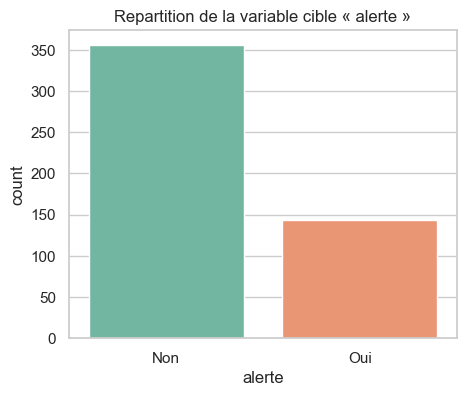

In [37]:
# Point 18 : deséquilibre des classes sur la variable cible "alerte"
alerte_counts = df["alerte"].value_counts(normalize=True) * 100
print(alerte_counts.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x="alerte", data=df, hue="alerte", legend=False, palette="Set2")
plt.title("Repartition de la variable cible « alerte »")
plt.show()

## Point 18 — Conclusion sur le déséquilibre des classes

La variable `alerte` présente un déséquilibre modéré : environ 71% de "Non" contre 29% de "Oui". Ce n'est pas un déséquilibre extrême (on serait plus préoccupé face à un ratio du type 95%/5%), mais il est suffisant pour justifier une **stratification** lors du découpage train/test (Partie 3), afin de conserver ces mêmes proportions dans les deux ensembles et éviter qu'un des deux ne se retrouve avec une classe sous-représentée de façon disproportionnée.

19) Pour la corrélation sur les variables numériques :
a) visualiser avec seaborn, la matrice de corrélation.
b) identifier les corrélations positives, négatives et les variables faiblement corrélées.

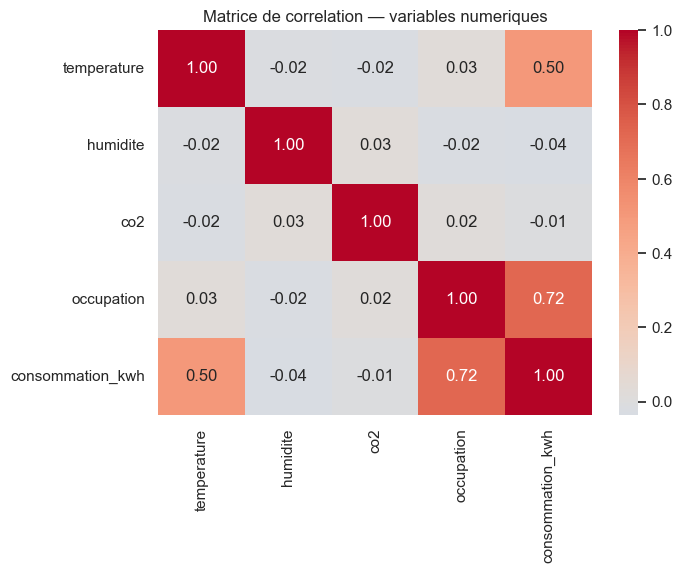

,temperature,humidite,co2,occupation,consommation_kwh
temperature,1.000000,-0.015463,-0.022913,0.031489,0.499415
humidite,-0.015463,1.000000,0.028554,-0.020589,-0.036326
co2,-0.022913,0.028554,1.000000,0.017836,-0.009514
occupation,0.031489,-0.020589,0.017836,1.000000,0.718195
consommation_kwh,0.499415,-0.036326,-0.009514,0.718195,1.000000


In [38]:
# Point 19a : visualiser la matrice de correlation avec seaborn
plt.figure(figsize=(7, 5))
corr = df[variables_numeriques].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de correlation — variables numeriques")
plt.show()
corr

## Point 19b — Interprétation de la matrice de corrélation

- **Corrélation positive forte** : `occupation` et `consommation_kwh` (0.72) — plus il y a de personnes dans le bâtiment, plus la consommation énergétique est élevée. C'est la relation la plus marquée du dataset.
- **Corrélation positive modérée** : `temperature` et `consommation_kwh` (0.50) — une température plus élevée s'accompagne d'une consommation plus importante (climatisation davantage sollicitée).
- **Corrélations négatives** : toutes très faibles, proches de 0 (ex. `humidite`/`consommation_kwh` = -0.04, `temperature`/`co2` = -0.02) — aucune relation négative significative dans ce dataset.
- **Variables faiblement corrélées avec le reste** : `humidite` et `co2` n'ont de corrélation notable avec aucune autre variable (toutes leurs valeurs sont proches de 0, entre -0.04 et 0.03) — elles apportent une information plutôt indépendante et complémentaire au modèle.

Partie 2 – Séparation X / y

Définir la variable "alerte" comme la cible y
Trouver des variables explicatives X pertinentes
Afficher les cinq premières lignes de X ainsi que de y

In [39]:
# Point 1 : definir "alerte" comme variable cible y
y = df["alerte"]

# Point 2 : definir les variables explicatives X
# On exclut : alerte (c'est la cible), id_mesure (identifiant, sans valeur predictive),
# date (variable brute peu exploitable telle quelle par un modele)
X = df.drop(columns=["alerte", "id_mesure", "date"])

print("X :", X.shape, " y :", y.shape)

X : (500, 11)  y : (500,)


In [40]:
# Point 3 : afficher les 5 premieres lignes de X et de y
X.head()

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine
0,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi
1,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi
2,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche
3,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche
4,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi


In [41]:
y.head()

0    Non
1    Non
2    Oui
3    Non
4    Non
Name: alerte, dtype: object

Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test). Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que dans les données d'origine.

In [42]:
# Partie 3 : decoupage train/test
# test_size=0.20 -> 20% pour le test
# random_state=RANDOM_STATE -> garantit la reproductibilite (meme decoupage a chaque execution)
# stratify=y -> conserve les memes proportions de classes (Oui/Non) dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train :", X_train.shape, " Test :", X_test.shape)
print("Proportions train :")
print(y_train.value_counts(normalize=True).round(3))
print("Proportions test :")
print(y_test.value_counts(normalize=True).round(3))

Train : (400, 11)  Test : (100, 11)
Proportions train :
alerte
Non    0.712
Oui    0.288
Name: proportion, dtype: float64
Proportions test :
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64


## Partie 4 — Choix de l'encodage par variable catégorielle

- **batiment** (8 valeurs B1 à B8, nominal, pas d'ordre) → **One-Hot Encoding**.
- **type_batiment** (nominal, ~6 catégories) → **One-Hot Encoding**.
- **zone** (nominal, 4 valeurs A/B/C/D) → **One-Hot Encoding**.
- **mode_climatisation** (Eco / Normal / Boost) → a un ordre naturel d'intensité, mais on choisit un **One-Hot Encoding** pour éviter d'imposer un poids numérique arbitraire (ex. Eco=0, Normal=1, Boost=2 sous-entendrait que Boost "vaut le double" de Normal, ce qui n'a pas de sens physique) — choix documenté, un encodage ordinal serait une alternative valable.
- **etat_systeme** (Normal / Alerte / Panne, nominal) → **One-Hot Encoding**.
- **jour_semaine** (nominal, cyclique) → **One-Hot Encoding** (une transformation cyclique sin/cos serait une alternative plus avancée, proposée en bonus).

On utilise `OneHotEncoder(handle_unknown="ignore")` de Scikit-learn : le paramètre `handle_unknown="ignore"` rend l'encodeur robuste si une catégorie rare, vue seulement dans le test set (ou en production), n'a jamais été vue à l'entraînement.

In [43]:
# Demonstration de l'encodage One-Hot sur une variable, ici mode_climatisation
variables_categorielles_X = ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme", "jour_semaine"]
variables_numeriques_X = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]

ohe_demo = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
apercu_encodage = ohe_demo.fit_transform(X_train[["mode_climatisation"]].astype(str))
pd.DataFrame(apercu_encodage, columns=ohe_demo.get_feature_names_out(["mode_climatisation"])).head()

,mode_climatisation_Boost,mode_climatisation_Eco,mode_climatisation_Normal,mode_climatisation_nan
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0


Partie 5 – Mise à l'échelle 
1) A l’aide de quelques variables, justifier la pertinence de la mise à l’échelle 
2) Appliquer et justifier une technique de mise à l'échelle 
3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?

In [44]:
# Point 1 : justifier la pertinence de la mise a l'echelle
# On regarde les ordres de grandeur (min, max, moyenne, ecart-type) des variables numeriques
X_train[variables_numeriques_X].agg(["min", "max", "mean", "std"]).T

,min,max,mean,std
temperature,12.3,34.2,23.800518,3.291658
humidite,21.5,89.5,57.008073,12.096141
co2,89.0,6000.0,838.164975,558.102912
occupation,0.0,116.0,45.521739,24.762956
consommation_kwh,26.4,336.2,170.468878,51.221598


## Point 1 — Pertinence de la mise à l'échelle

Les variables numériques n'ont pas du tout la même échelle : `co2` varie sur plusieurs centaines/milliers de ppm, alors que `temperature` varie seulement entre environ 10 et 35°C, et `occupation` entre 0 et une centaine de personnes.

Sans mise à l'échelle, un algorithme sensible aux distances entre points (KNN, SVM, régression logistique régularisée, réseaux de neurones) donnerait artificiellement beaucoup plus de poids à `co2` simplement parce que ses valeurs numériques sont plus grandes — pas parce que cette variable est réellement plus importante pour prédire une alerte. La mise à l'échelle remet toutes les variables sur un pied d'égalité avant l'apprentissage.

In [45]:
# Point 2 : appliquer le StandardScaler
# fit_transform sur X_train : apprend la moyenne/ecart-type ET transforme
# transform seul sur X_test : applique les MEMES parametres appris sur train (pas de nouveau calcul)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train[variables_numeriques_X])
X_test_num_scaled = scaler.transform(X_test[variables_numeriques_X])

pd.DataFrame(X_train_num_scaled, columns=variables_numeriques_X).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
temperature,386.0,-0.0,1.0,-3.50,-0.64,0.03,0.64,3.16
humidite,384.0,0.0,1.0,-2.94,-0.58,-0.00,0.65,2.69
co2,394.0,0.0,1.0,-1.34,-0.38,-0.10,0.20,9.26
occupation,391.0,0.0,1.0,-1.84,-0.75,0.02,0.63,2.85
consommation_kwh,392.0,0.0,1.0,-2.82,-0.68,-0.02,0.68,3.24


## Point 2 — Justification du choix du StandardScaler

On choisit le **StandardScaler** (centrage-réduction : transforme chaque variable pour qu'elle ait une moyenne de 0 et un écart-type de 1) plutôt qu'un `MinMaxScaler` (qui ramène les valeurs entre 0 et 1), car :
- Nos variables ne sont pas naturellement bornées dans un intervalle fixe et connu à l'avance.
- Certaines variables (ex. `co2`) contiennent encore des valeurs modérément élevées après nettoyage — le StandardScaler est moins sensible que le MinMaxScaler à quelques valeurs hautes isolées, car il se base sur la moyenne et l'écart-type plutôt que sur le min/max exact.

## Point 3 — Pourquoi ne pas calculer moyenne/écart-type sur le dataset complet ?

Si l'on calculait la moyenne et l'écart-type sur l'ensemble des données (train + test réunis) avant de séparer, les statistiques de mise à l'échelle « verraient » indirectement des informations issues du test set — c'est ce qu'on appelle une **fuite de données (data leakage)**.

Concrètement, le modèle serait ensuite évalué de façon trop optimiste : ses performances sur le test sembleraient meilleures qu'elles ne le seraient réellement en production, car le prétraitement du test aurait déjà "profité" d'informations tirées du test lui-même — ce qui n'est pas représentatif d'une vraie situation où le modèle rencontre des données jamais vues.

La bonne pratique, appliquée au point 2, est donc : apprendre (`fit`) le scaler **uniquement** sur `X_train`, puis l'appliquer (`transform`) tel quel, sans le réapprendre, sur `X_test`.

partie 6 :Pipeline de preprocessing

In [46]:
# Construction du pipeline de preprocessing complet avec Scikit-learn

# Sous-pipeline pour les variables numeriques : imputation mediane puis mise a l'echelle
transformateur_numerique = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="median")),
    ("mise_a_echelle", StandardScaler()),
])

# Sous-pipeline pour les variables categorielles : imputation par le mode puis One-Hot Encoding
transformateur_categoriel = Pipeline(steps=[
    ("imputation", SimpleImputer(strategy="most_frequent")),
    ("encodage", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer : applique chaque sous-pipeline aux bonnes colonnes, en parallele
preprocessing = ColumnTransformer(transformers=[
    ("num", transformateur_numerique, variables_numeriques_X),
    ("cat", transformateur_categoriel, variables_categorielles_X),
])

pipeline_preprocessing = Pipeline(steps=[("preprocessing", preprocessing)])
pipeline_preprocessing

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputation',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('mise_a_echelle',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidite',
                                                   'co2', 'occupation',
                                                   'consommation_kwh']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputation',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encodage',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['batiment', 'type_batiment',
                                                   'zone', 'mode_climatisation',
                                                   'etat_systeme',
                                                   'jour_semaine'])]))])

In [47]:
# Application du pipeline : fit sur train, transform sur train et test (pas de fuite de donnees)
X_train_prepared = pipeline_preprocessing.fit_transform(X_train)
X_test_prepared = pipeline_preprocessing.transform(X_test)

print("Forme X_train prepare :", X_train_prepared.shape)
print("Forme X_test prepare  :", X_test_prepared.shape)

Forme X_train prepare : (400, 36)
Forme X_test prepare  : (100, 36)


Partie 7 : Exportation

In [48]:
# Partie 7 : exporter le dataframe nettoye (df, avant encodage/scaling) vers exports/
import os
os.makedirs("../exports", exist_ok=True)
df.to_csv("../exports/smart_building_cleaned.csv", index=False)
print("Fichier exporte :", os.path.abspath("../exports/smart_building_cleaned.csv"))
print("Dimensions finales :", df.shape)

Fichier exporte : c:\Users\dell\Desktop\atelier_prepa_donnees_tab\exports\smart_building_cleaned.csv
Dimensions finales : (500, 14)
